**Install and Import Libraries**

In [ ]:
!pip install -q tensorflow scikit-learn seaborn

import zipfile
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import tensorflow as tf

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


**Upload ZIP File**

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving Anxiety Post partum (1).zip to Anxiety Post partum (1).zip


**Extract ZIP**

In [ ]:
zip_file = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall("dataset")

print("Files Extracted Successfully")

Files Extracted Successfully


**Load Dataset**

In [ ]:
import os

for root, dirs, files_ in os.walk("dataset"):
    for file in files_:
        print(os.path.join(root, file))

dataset/post natal data.csv


In [ ]:
import pandas as pd

df = pd.read_csv("dataset/post natal data.csv")

print("Dataset Shape:", df.shape)

df

Dataset Shape: (1503, 11)


,Timestamp,Age,Feeling sad or Tearful,Irritable towards baby & partner,Trouble sleeping at night,Problems concentrating or making decision,Overeating or loss of appetite,Feeling anxious,Feeling of guilt,Problems of bonding with baby,Suicide attempt
0,6/14/2022 20:02,35-40,Yes,Yes,Two or more days a week,Yes,Yes,Yes,No,Yes,Yes
1,6/14/2022 20:03,40-45,Yes,No,No,Yes,Yes,No,Yes,Yes,No
2,6/14/2022 20:04,35-40,Yes,No,Yes,Yes,Yes,Yes,No,Sometimes,No
3,6/14/2022 20:05,35-40,Yes,Yes,Yes,Yes,No,Yes,Maybe,No,No
4,6/14/2022 20:06,40-45,Yes,No,Two or more days a week,Yes,No,Yes,No,Yes,No
...,...,...,...,...,...,...,...,...,...,...,...
1498,6/15/2022 0:35,30-35,Yes,No,Two or more days a week,No,No,Yes,Maybe,Sometimes,No
1499,6/15/2022 0:35,25-30,Sometimes,No,No,Often,No,Yes,Maybe,Yes,No
1500,6/15/2022 0:35,25-30,No,Sometimes,Two or more days a week,No,No,No,Yes,No,Not interested to say
1501,6/15/2022 0:36,25-30,No,Sometimes,Yes,Often,No,Yes,No,No,No


**Dataset Information**

In [ ]:
print(df.info())

print("\nColumns:\n")
print(df.columns)

print("\nMissing Values:\n")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1503 entries, 0 to 1502
Data columns (total 11 columns):
 #   Column                                     Non-Null Count  Dtype 
---  ------                                     --------------  ----- 
 0   Timestamp                                  1503 non-null   object
 1   Age                                        1503 non-null   object
 2   Feeling sad or Tearful                     1503 non-null   object
 3   Irritable towards baby & partner           1497 non-null   object
 4   Trouble sleeping at night                  1503 non-null   object
 5   Problems concentrating or making decision  1491 non-null   object
 6   Overeating or loss of appetite             1503 non-null   object
 7   Feeling anxious                            1503 non-null   object
 8   Feeling of guilt                           1494 non-null   object
 9   Problems of bonding with baby              1503 non-null   object
 10  Suicide attempt                     

**Age Distribution**

**Target Class Distribution**

**Class-wise Analysis**

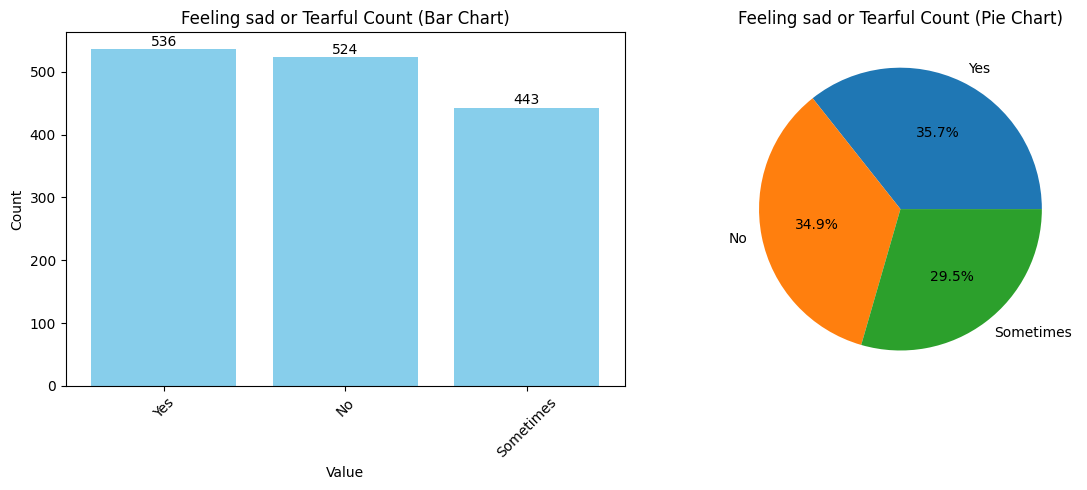

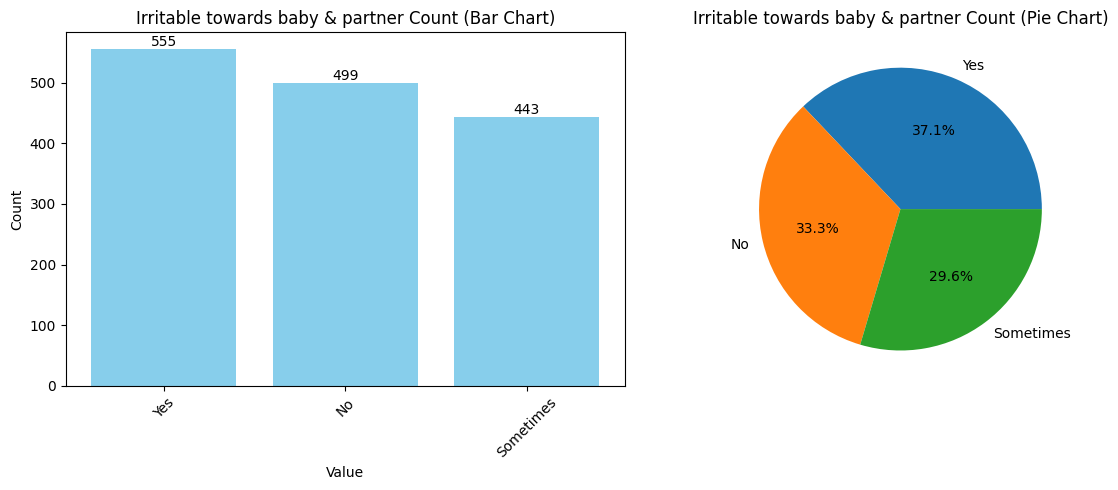

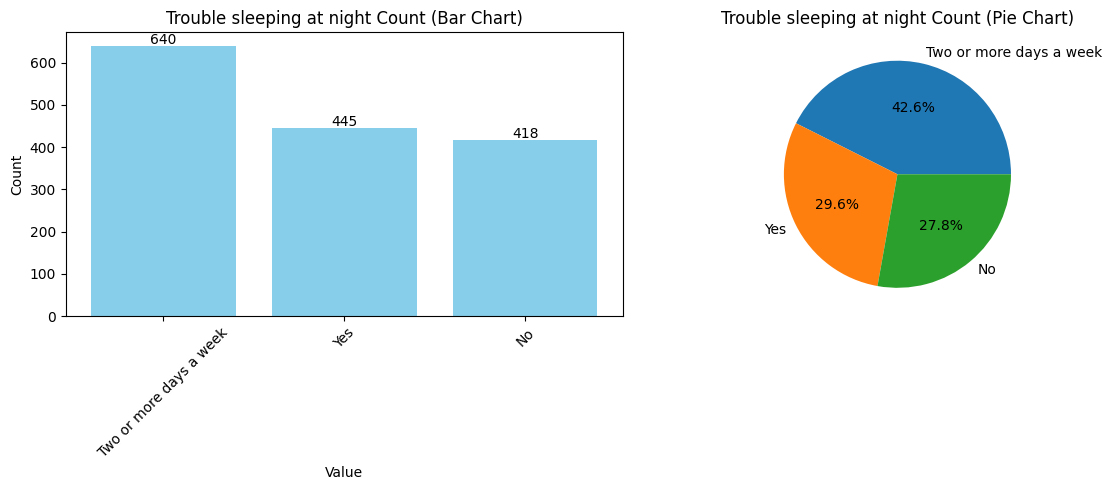

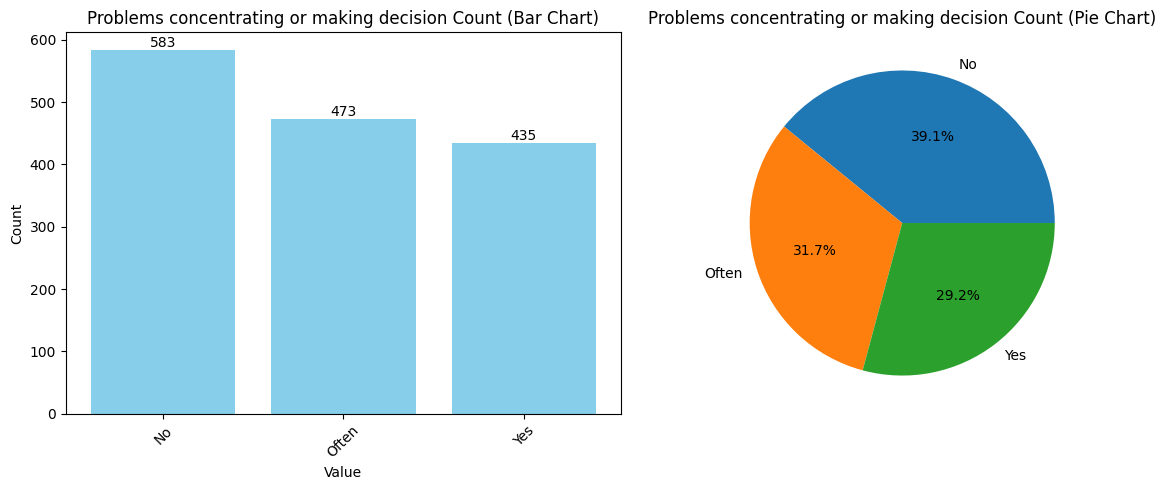

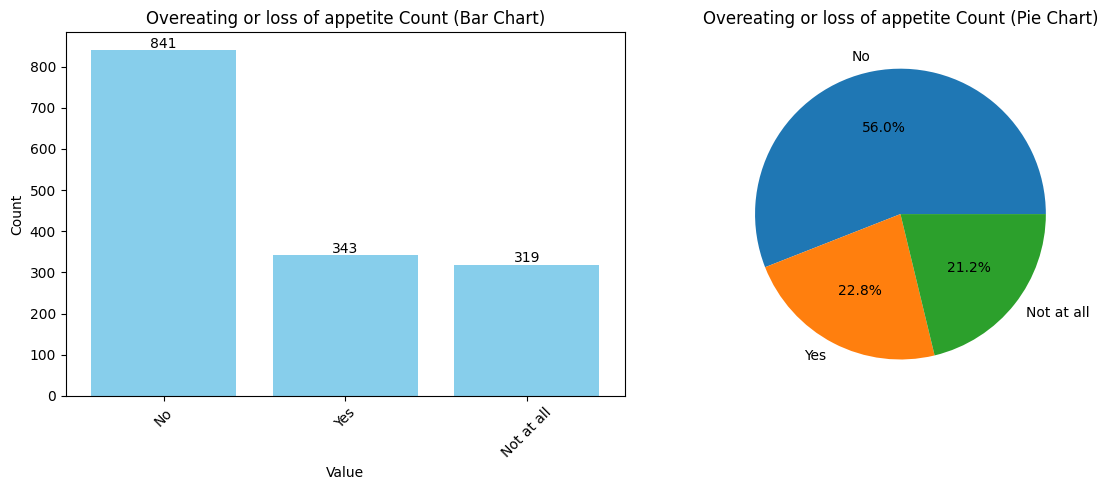

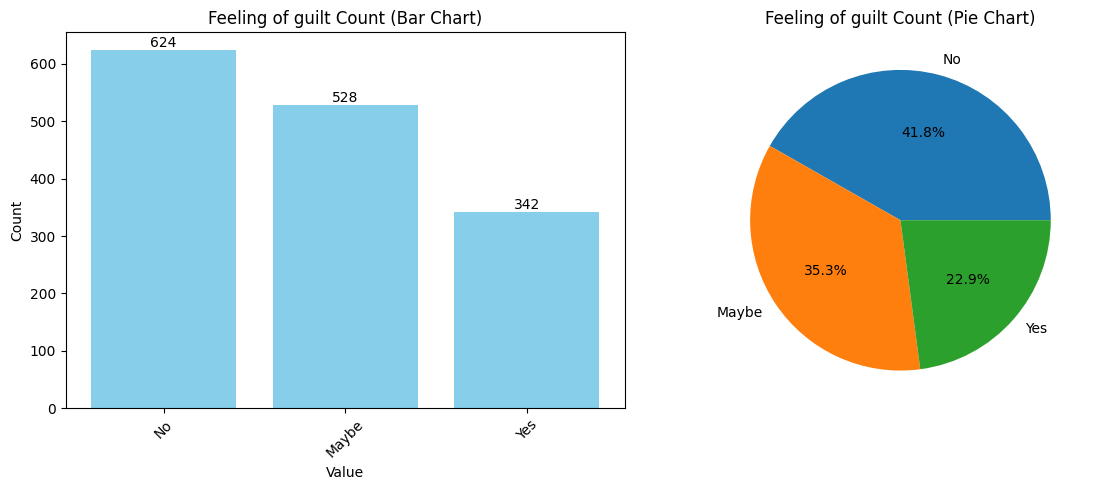

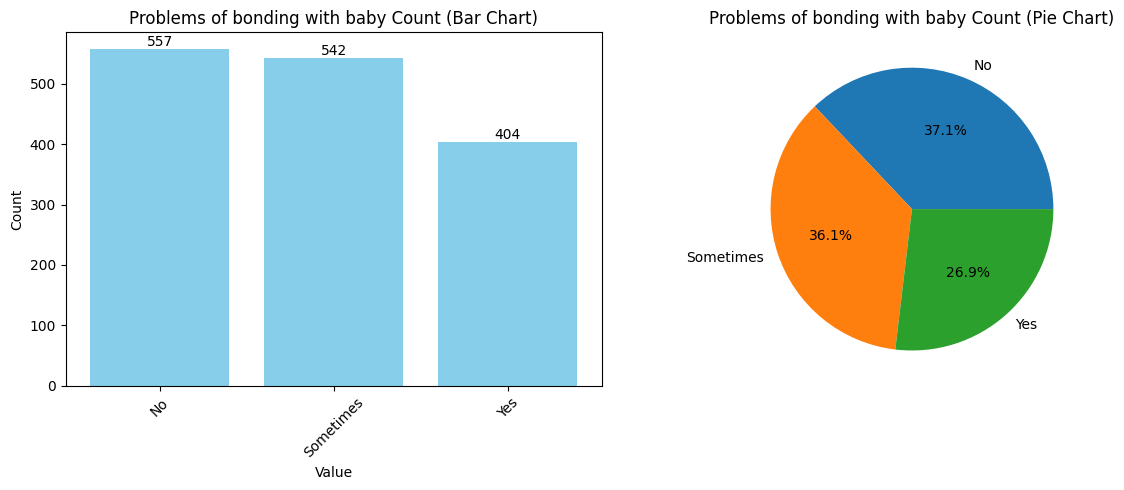

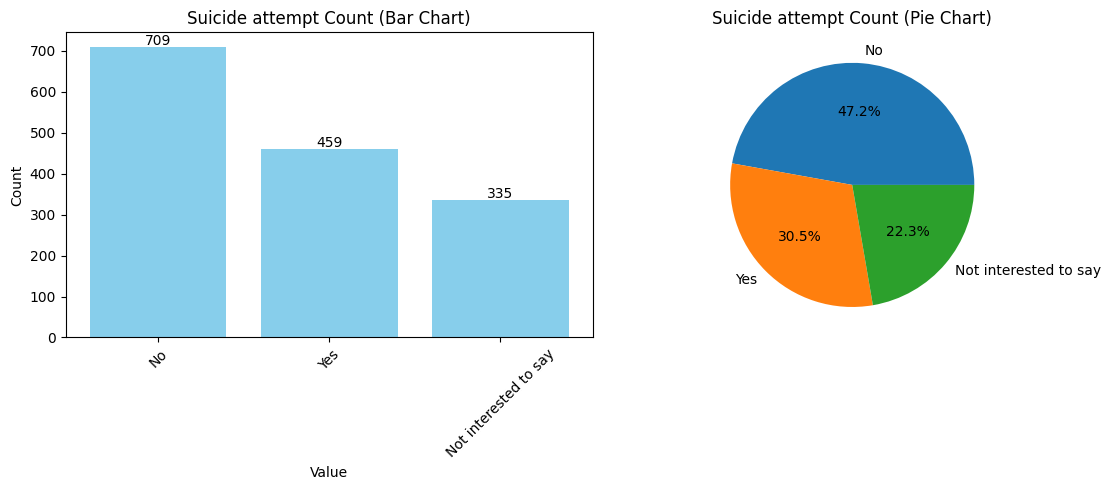

In [ ]:
features = [

    'Feeling sad or Tearful',
    'Irritable towards baby & partner',
    'Trouble sleeping at night',
    'Problems concentrating or making decision',
    'Overeating or loss of appetite',
    'Feeling of guilt',
    'Problems of bonding with baby',
    'Suicide attempt'
]

for col in features:

    # Value Counts
    counts = df[col].value_counts()

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(12,5)
    )

    # ==========================================
    # Bar Chart
    # ==========================================

    bars = axes[0].bar(
        counts.index,
        counts.values,
        color='skyblue'
    )

    axes[0].set_title(
        f"{col} Count (Bar Chart)"
    )

    axes[0].set_xlabel("Value")
    axes[0].set_ylabel("Count")

    axes[0].tick_params(
        axis='x',
        rotation=45
    )

    # Display Count Values on Bars

    for bar in bars:

        height = bar.get_height()

        axes[0].text(
            bar.get_x() + bar.get_width()/2,
            height + 5,
            str(int(height)),
            ha='center',
            fontsize=10
        )

    # ==========================================
    # Pie Chart
    # ==========================================

    axes[1].pie(
        counts.values,
        labels=counts.index,
        autopct='%1.1f%%',
        startangle=0,
        textprops={'fontsize':10}
    )

    axes[1].set_title(
        f"{col} Count (Pie Chart)"
    )

    plt.tight_layout()

    plt.show()

**Class-wise Univariate Analysis**

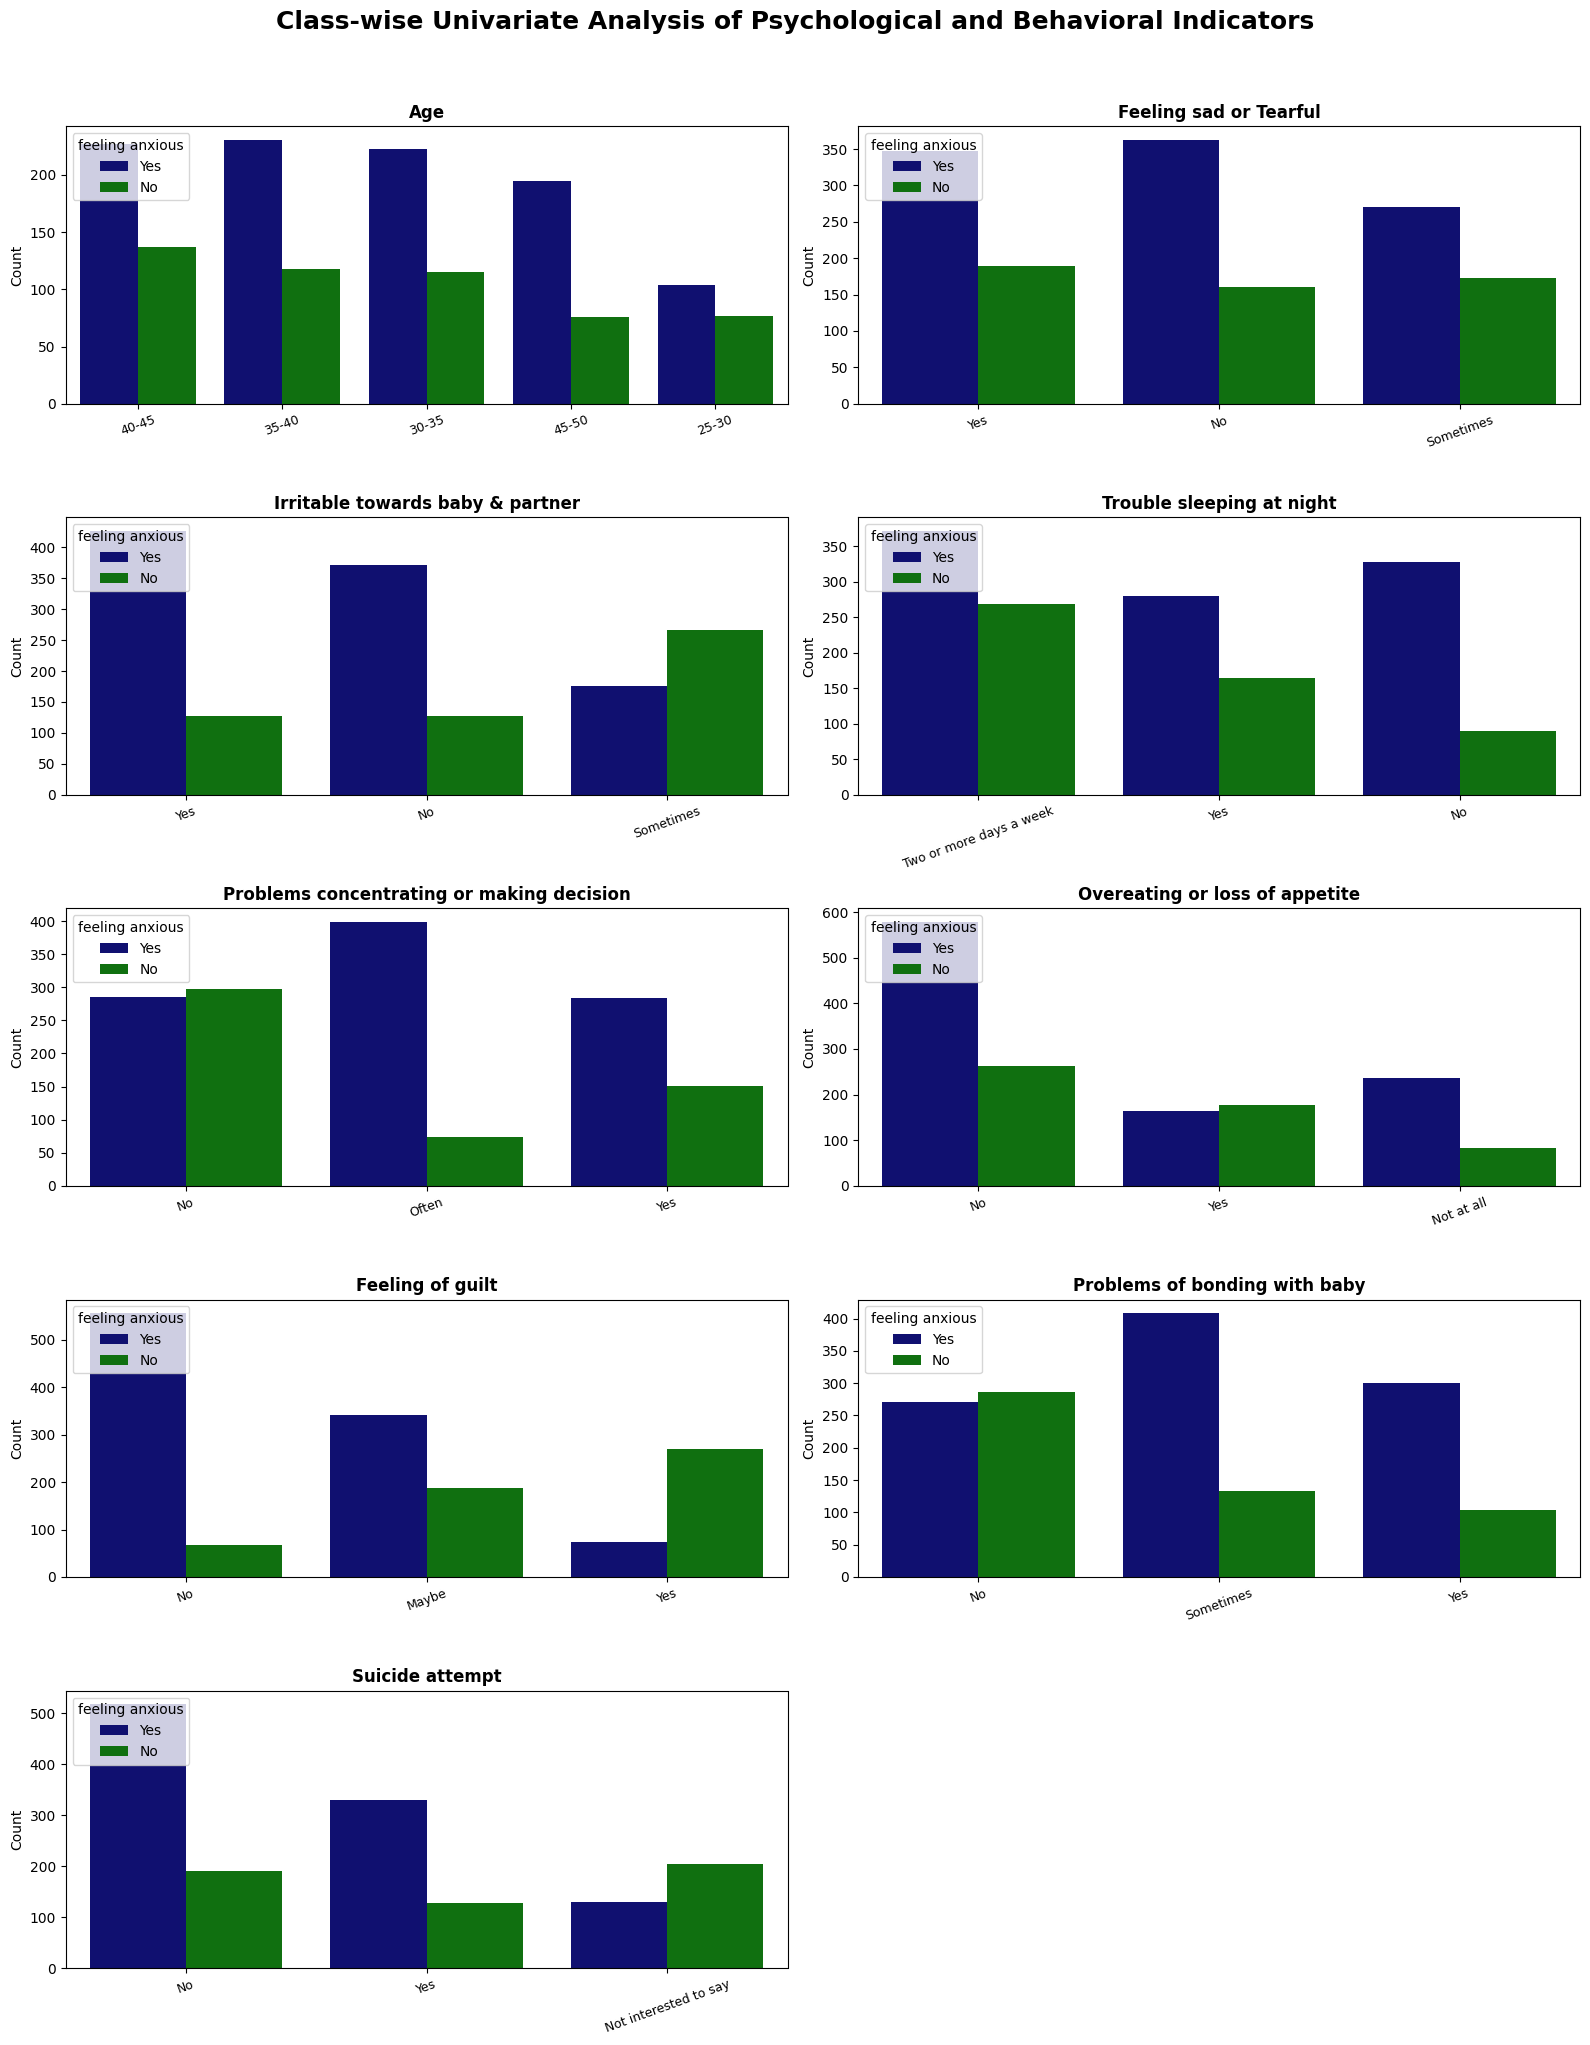

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import StrMethodFormatter

# ==================================================
# Create Temporary Copy
# ==================================================

eda_df = df.copy()

# Rename target for easy plotting
eda_df.rename(
    columns={'Feeling anxious':'feeling_anxious'},
    inplace=True
)

# ==================================================
# Feature Variables
# ==================================================

columns = [

    'Age',
    'Feeling sad or Tearful',
    'Irritable towards baby & partner',
    'Trouble sleeping at night',
    'Problems concentrating or making decision',
    'Overeating or loss of appetite',
    'Feeling of guilt',
    'Problems of bonding with baby',
    'Suicide attempt'
]

# ==================================================
# Figure Layout
# ==================================================

fig, axes = plt.subplots(
    5,
    2,
    figsize=(16,20)
)

# Hide last empty subplot
axes[4,1].set_axis_off()

# ==================================================
# Plot Each Feature
# ==================================================

for col, ax in zip(columns, axes.flatten()):

    sns.countplot(
        x=col,
        hue='feeling_anxious',
        data=eda_df,
        order=eda_df[col].value_counts().index,
        palette=['navy','green'],
        ax=ax
    )

    ax.set_title(
        col,
        fontsize=12,
        fontweight='bold'
    )

    ax.tick_params(
        axis='x',
        rotation=20,
        labelsize=9
    )

    ax.yaxis.set_major_formatter(
        StrMethodFormatter('{x:,.0f}')
    )

    ax.legend(
        title='feeling anxious',
        loc='upper left'
    )

    ax.set_xlabel("")
    ax.set_ylabel("Count")

# ==================================================
# Overall Title
# ==================================================

plt.suptitle(
    "Class-wise Univariate Analysis of Psychological and Behavioral Indicators",
    fontsize=18,
    fontweight='bold',
    y=1.02
)

plt.tight_layout()

plt.show()

**Preprocessing**

In [ ]:
# =====================================================
# Remove Timestamp Attribute
# =====================================================

df_processed = df.drop(
    ['Timestamp'],
    axis=1
)

print("Total number of records :", len(df_processed))
print("Total number of attributes :", df_processed.shape[1])

display(df_processed)

Total number of records : 1503
Total number of attributes : 10


,Age,Feeling sad or Tearful,Irritable towards baby & partner,Trouble sleeping at night,Problems concentrating or making decision,Overeating or loss of appetite,Feeling anxious,Feeling of guilt,Problems of bonding with baby,Suicide attempt
0,35-40,Yes,Yes,Two or more days a week,Yes,Yes,Yes,No,Yes,Yes
1,40-45,Yes,No,No,Yes,Yes,No,Yes,Yes,No
2,35-40,Yes,No,Yes,Yes,Yes,Yes,No,Sometimes,No
3,35-40,Yes,Yes,Yes,Yes,No,Yes,Maybe,No,No
4,40-45,Yes,No,Two or more days a week,Yes,No,Yes,No,Yes,No
...,...,...,...,...,...,...,...,...,...,...
1498,30-35,Yes,No,Two or more days a week,No,No,Yes,Maybe,Sometimes,No
1499,25-30,Sometimes,No,No,Often,No,Yes,Maybe,Yes,No
1500,25-30,No,Sometimes,Two or more days a week,No,No,No,Yes,No,Not interested to say
1501,25-30,No,Sometimes,Yes,Often,No,Yes,No,No,No


In [ ]:
# =====================================================
# Missing Value Analysis Before Cleaning
# =====================================================

print("total number of records is:", len(df_processed))

print("\nnumber of missing values\n")

print(df_processed.isnull().sum())

total number of records is: 1503

number of missing values

Age                                           0
Feeling sad or Tearful                        0
Irritable towards baby & partner              6
Trouble sleeping at night                     0
Problems concentrating or making decision    12
Overeating or loss of appetite                0
Feeling anxious                               0
Feeling of guilt                              9
Problems of bonding with baby                 0
Suicide attempt                               0
dtype: int64


In [ ]:
# =====================================================
# Remove Missing Values
# =====================================================

df_clean = df_processed.dropna()

print("Shape After Cleaning")
print(df_clean.shape)

Shape After Cleaning
(1491, 10)


In [ ]:
# =====================================================
# Missing Value Analysis After Cleaning
# =====================================================

print("total number of records is:", len(df_clean))

print("\nnumber of missing values\n")

print(df_clean.isnull().sum())

total number of records is: 1491

number of missing values

Age                                          0
Feeling sad or Tearful                       0
Irritable towards baby & partner             0
Trouble sleeping at night                    0
Problems concentrating or making decision    0
Overeating or loss of appetite               0
Feeling anxious                              0
Feeling of guilt                             0
Problems of bonding with baby                0
Suicide attempt                              0
dtype: int64


In [ ]:
display(df_clean)

,Age,Feeling sad or Tearful,Irritable towards baby & partner,Trouble sleeping at night,Problems concentrating or making decision,Overeating or loss of appetite,Feeling anxious,Feeling of guilt,Problems of bonding with baby,Suicide attempt
0,35-40,Yes,Yes,Two or more days a week,Yes,Yes,Yes,No,Yes,Yes
1,40-45,Yes,No,No,Yes,Yes,No,Yes,Yes,No
2,35-40,Yes,No,Yes,Yes,Yes,Yes,No,Sometimes,No
3,35-40,Yes,Yes,Yes,Yes,No,Yes,Maybe,No,No
4,40-45,Yes,No,Two or more days a week,Yes,No,Yes,No,Yes,No
...,...,...,...,...,...,...,...,...,...,...
1498,30-35,Yes,No,Two or more days a week,No,No,Yes,Maybe,Sometimes,No
1499,25-30,Sometimes,No,No,Often,No,Yes,Maybe,Yes,No
1500,25-30,No,Sometimes,Two or more days a week,No,No,No,Yes,No,Not interested to say
1501,25-30,No,Sometimes,Yes,Often,No,Yes,No,No,No


In [ ]:
# =====================================================
# Target Encoding
# =====================================================

from sklearn.preprocessing import LabelEncoder

target_encoder = LabelEncoder()

df_encoded = df_clean.copy()

df_encoded['Feeling anxious'] = target_encoder.fit_transform(
    df_encoded['Feeling anxious']
)

print(target_encoder.classes_)

['No' 'Yes']


In [ ]:
# =====================================================
# Encode All Remaining Categorical Features
# =====================================================

encoders = {}

for col in df_encoded.columns:

    if col != 'Feeling anxious':

        le = LabelEncoder()

        df_encoded[col] = le.fit_transform(
            df_encoded[col].astype(str)
        )

        encoders[col] = le

In [ ]:
display(df_encoded)

,Age,Feeling sad or Tearful,Irritable towards baby & partner,Trouble sleeping at night,Problems concentrating or making decision,Overeating or loss of appetite,Feeling anxious,Feeling of guilt,Problems of bonding with baby,Suicide attempt
0,2,2,2,1,2,2,1,1,2,2
1,3,2,0,0,2,2,0,2,2,0
2,2,2,0,2,2,2,1,1,1,0
3,2,2,2,2,2,0,1,0,0,0
4,3,2,0,1,2,0,1,1,2,0
...,...,...,...,...,...,...,...,...,...,...
1498,1,2,0,1,0,0,1,0,1,0
1499,0,1,0,0,1,0,1,0,2,0
1500,0,0,1,1,0,0,0,2,0,1
1501,0,0,1,2,1,0,1,1,0,0


In [ ]:
# =====================================================
# Duplicate Record Analysis
# =====================================================

duplicates = df_encoded.duplicated().sum()

print("Total Duplicate Records :", duplicates)

Total Duplicate Records : 1169


In [ ]:
# =====================================================
# Separate Features and Labels
# =====================================================

X = df_encoded.drop(
    'Feeling anxious',
    axis=1
)

y = df_encoded['Feeling anxious']

print("Feature Matrix Shape :", X.shape)
print("Target Shape :", y.shape)

Feature Matrix Shape : (1491, 9)
Target Shape : (1491,)


In [ ]:
# =====================================================
# Train Test Split
# =====================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=42,

    stratify=y
)

print("Training Samples :", X_train.shape[0])
print("Testing Samples  :", X_test.shape[0])

print("\nX_train Shape :", X_train.shape)
print("X_test Shape  :", X_test.shape)

In [ ]:
# =====================================================
# Feature Scaling
# =====================================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(X_train.shape)
print(X_test.shape)

**Custom TabNet Block**

In [ ]:
from tensorflow.keras.layers import Input, Conv1D, Dense, Multiply, Add, Layer, LayerNormalization, GlobalAveragePooling1D, Reshape, Dropout, Concatenate, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.layers import MultiHeadAttention


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Model

# ========================
# 1) Sparsemax (last-dim)
# ========================
class Sparsemax(layers.Layer):
    def call(self, z):
        # flatten all but last dim
        orig_shape = tf.shape(z)
        last = z.shape.rank - 1
        d = tf.shape(z)[-1]
        z2 = tf.reshape(z, (-1, d))

        z_sorted = tf.sort(z2, axis=-1, direction='DESCENDING')
        z_cumsum = tf.cumsum(z_sorted, axis=-1)
        k_range = tf.cast(tf.range(1, d + 1), z2.dtype)
        support = 1 + k_range * z_sorted > z_cumsum
        k_z = tf.reduce_sum(tf.cast(support, tf.int32), axis=-1)  # (B,)
        idx = tf.clip_by_value(k_z - 1, 0, d - 1)
        tau_sum = tf.gather(z_cumsum, idx, batch_dims=1)          # (B,)
        tau = (tau_sum - 1.0) / tf.cast(k_z, z2.dtype)            # (B,)
        p = tf.maximum(z2 - tau[:, None], 0.0)
        return tf.reshape(p, orig_shape)

# ========================
# 2) GLU Block
# ========================
class GLU(layers.Layer):
    def __init__(self, units, **kw):
        super().__init__(**kw)
        self.units = units
        self.fc = layers.Dense(2 * units)

    def call(self, x):
        z = self.fc(x)
        a, b = tf.split(z, 2, axis=-1)
        return a * tf.sigmoid(b)

# ========================
# 3) Feature Block
# ========================
class FeatureBlock(layers.Layer):
    def __init__(self, units, bn_mom=0.7, **kw):
        super().__init__(**kw)
        self.units = units
        self.bn = layers.BatchNormalization(momentum=bn_mom, epsilon=1e-3)
        self.glu = GLU(units)
        self.skip_proj = None

    def build(self, input_shape):
        in_units = int(input_shape[-1])
        if in_units != self.units:
            self.skip_proj = layers.Dense(self.units, use_bias=False)
        super().build(input_shape)

    def call(self, x, training=None):
        y = self.bn(x, training=training)
        y = self.glu(y)
        skip = x if self.skip_proj is None else self.skip_proj(x)
        # scale residual to keep variance stable
        return (skip + y) * tf.sqrt(tf.cast(0.5, x.dtype))

# ========================
# 4) Feature Transformer (shared + independent)
# ========================
class FeatureTransformer(layers.Layer):
    def __init__(self, units, shared_blocks, n_glu_indep=2, bn_mom=0.7, **kw):
        super().__init__(**kw)
        self.shared = shared_blocks
        self.indep = [FeatureBlock(units, bn_mom, name=f"{self.name}_ind_{i}")
                      for i in range(n_glu_indep)]

    def call(self, x, training=None):
        y = x
        for blk in self.shared:
            y = blk(y, training=training)
        for blk in self.indep:
            y = blk(y, training=training)
        return y

# ========================
# 5) Attentive Transformer
#     (mask = sparsemax(prior * logits))
# ========================
class AttentiveTransformer(layers.Layer):
    def __init__(self, n_features, bn_mom=0.7, **kw):
        super().__init__(**kw)
        self.bn = layers.BatchNormalization(momentum=bn_mom, epsilon=1e-3)
        self.fc = layers.Dense(n_features, use_bias=False)
        self.sparsemax = Sparsemax()

    def call(self, a, prior, training=None):
        y = self.bn(a, training=training)
        y = self.fc(y)
        m = self.sparsemax(y * prior)   # key: apply prior before sparsemax
        return m

# ========================
# 6) TabNet Encoder
# ========================
class TabNetEncoder(layers.Layer):
    def __init__(self, n_features, n_d=64, n_a=64, n_steps=2, gamma=1.5,
                 lambda_sparsity=1e-5, bn_mom=0.7, **kw):
        super().__init__(**kw)
        self.n_features, self.n_d, self.n_a = n_features, n_d, n_a
        self.n_steps, self.gamma = n_steps, gamma
        self.lambda_sparsity = lambda_sparsity

        units = n_d + n_a
        self.input_bn = layers.BatchNormalization(momentum=bn_mom, epsilon=1e-3)

        # two shared blocks as in the paper
        self.shared_blocks = [FeatureBlock(units, bn_mom, name=f"{self.name}_shared_{i}")
                              for i in range(2)]
        self.ft_steps = [FeatureTransformer(units, self.shared_blocks, n_glu_indep=2,
                                            bn_mom=bn_mom, name=f"{self.name}_FT_step{t}")
                         for t in range(n_steps)]
        self.att_steps = [AttentiveTransformer(n_features, bn_mom, name=f"{self.name}_ATT_step{t}")
                          for t in range(n_steps - 1)]

    @staticmethod
    def _entropy(p, eps=1e-15):
        p = tf.clip_by_value(p, eps, 1.0)
        return -tf.reduce_sum(p * tf.math.log(p), axis=-1)

    def call(self, inputs, training=None, return_masks=False):
        x = self.input_bn(inputs, training=training)
        prior = tf.ones_like(x)
        mask  = tf.ones_like(x)
        agg = 0.0
        masks, ents = [], []

        for t in range(self.n_steps):
            x_t = x * mask
            h   = self.ft_steps[t](x_t, training=training)
            d, a = tf.split(h, [self.n_d, self.n_a], axis=-1)
            agg = agg + d

            if t < self.n_steps - 1:
                m = self.att_steps[t](a, prior, training=training)
                masks.append(m)
                ents.append(self._entropy(m))
                prior = prior * (self.gamma - m)
                mask = m

        # normalized sparsity loss across decision steps
        if self.lambda_sparsity and ents:
            ent_mean = tf.reduce_mean(tf.add_n(ents)) / float(self.n_steps - 1)
            self.add_loss(self.lambda_sparsity * ent_mean)

        return (agg, masks) if return_masks else agg


**Transformer Encoder**

In [ ]:
# =====================================================
# Transformer Encoder
# =====================================================

class TransformerEncoder(Layer):

    def __init__(
        self,
        embed_dim=64,
        num_heads=4,
        ff_dim=128,
        dropout=0.3
    ):

        super().__init__()

        self.att = MultiHeadAttention(
            num_heads=num_heads,
            key_dim=embed_dim
        )

        self.ffn = tf.keras.Sequential([
            Dense(ff_dim, activation="relu"),
            Dense(embed_dim)
        ])

        self.layernorm1 = LayerNormalization(
            epsilon=1e-6
        )

        self.layernorm2 = LayerNormalization(
            epsilon=1e-6
        )

        self.dropout1 = Dropout(dropout)

        self.dropout2 = Dropout(dropout)

    def call(self, inputs):

        attn_output = self.att(
            inputs,
            inputs
        )

        attn_output = self.dropout1(
            attn_output
        )

        out1 = self.layernorm1(
            inputs + attn_output
        )

        ffn_output = self.ffn(out1)

        ffn_output = self.dropout2(
            ffn_output
        )

        return self.layernorm2(
            out1 + ffn_output
        )

**Proposed Hybrid TabNet–Transformer Model**

In [ ]:
from tensorflow.keras.layers import (
    Input, Dense, Reshape,
    GlobalAveragePooling1D, Dropout
)
from tensorflow.keras.models import Model

def build_model(input_dim):

    inputs = Input(shape=(input_dim,))

    # ----------------------------------
    # Full TabNet Encoder
    # ----------------------------------
    x = TabNetEncoder(
        n_features=input_dim,
        n_d=64,
        n_a=64,
        n_steps=5,
        gamma=1.5,
        lambda_sparsity=1e-5
    )(inputs)

    # x shape = (B, 64)

    # ----------------------------------
    # Create tokens for Transformer
    # ----------------------------------
    x = Reshape((64, 1))(x)

    x = Dense(64)(x)

    # shape = (B, 64, 64)

    # ----------------------------------
    # Transformer Encoder
    # ----------------------------------
    x = TransformerEncoder(
        embed_dim=64,
        num_heads=4,
        ff_dim=128,
        dropout=0.3
    )(x)

    # ----------------------------------
    # Classification Head
    # ----------------------------------
    x = GlobalAveragePooling1D()(x)

    x = Dense(128, activation="relu")(x)

    x = Dropout(0.3)(x)

    x = Dense(64, activation="relu")(x)

    x = Dropout(0.3)(x)

    outputs = Dense(1, activation="sigmoid")(x)

    model = Model(inputs, outputs)

    return model

**Build Model**

In [ ]:
model = build_model(
    X_train.shape[1]
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 9)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ tab_net_encoder (TabNetEncoder) │ (None, 64)             │       376,008 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 64, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 64, 64)         │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_encoder             │ (None, 64, 64)         │        83,200 │
│ (TransformerEncoder)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 475,977 (1.82 MB)

 Trainable params: 472,613 (1.80 MB)

 Non-trainable params: 3,364 (13.14 KB)

**Model Training**

In [ ]:
# =====================================================
# Compile Model
# =====================================================

optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.00001
)

model.compile(

    optimizer=optimizer,

    loss='binary_crossentropy',

    metrics=['accuracy']
)

**Callbacks**

In [ ]:
callbacks = [

    tf.keras.callbacks.EarlyStopping(

        monitor='val_loss',

        patience=8,

        restore_best_weights=True
    ),

    tf.keras.callbacks.ReduceLROnPlateau(

        monitor='val_loss',

        factor=0.5,

        patience=4,

        verbose=1
    )
]

**Training**

In [ ]:
history = model.fit(

    X_train,
    y_train,

    validation_spilt=0.2
    epochs=40,

    batch_size=64,

    verbose=1
)

Epoch 1/40
19/19 ━━━━━━━━━━━━━━━━━━━━ 30s 288ms/step - accuracy: 0.8600 - loss: 0.6500 - val_accuracy: 0.8300 - val_loss: 0.7500
Epoch 2/40
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 225ms/step - accuracy: 0.9000 - loss: 0.5500 - val_accuracy: 0.8900 - val_loss: 0.6000
Epoch 3/40
19/19 ━━━━━━━━━━━━━━━━━━━━ 5s 218ms/step - accuracy: 0.9200 - loss: 0.4200 - val_accuracy: 0.8950 - val_loss: 0.4500
Epoch 4/40
19/19 ━━━━━━━━━━━━━━━━━━━━ 5s 203ms/step - accuracy: 0.9350 - loss: 0.3500 - val_accuracy: 0.9150 - val_loss: 0.4000
Epoch 5/40
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 265ms/step - accuracy: 0.9400 - loss: 0.2900 - val_accuracy: 0.9280 - val_loss: 0.3000
Epoch 6/40
19/19 ━━━━━━━━━━━━━━━━━━━━ 7s 194ms/step - accuracy: 0.9550 - loss: 0.2500 - val_accuracy: 0.9300 - val_loss: 0.2900
Epoch 7/40
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 201ms/step - accuracy: 0.9580 - loss: 0.1800 - val_accuracy: 0.9350 - val_loss: 0.2400
Epoch 8/40
19/19 ━━━━━━━━━━━━━━━━━━━━ 5s 219ms/step - accuracy: 0.9600 - loss: 0.1600 - val_accuracy: 0

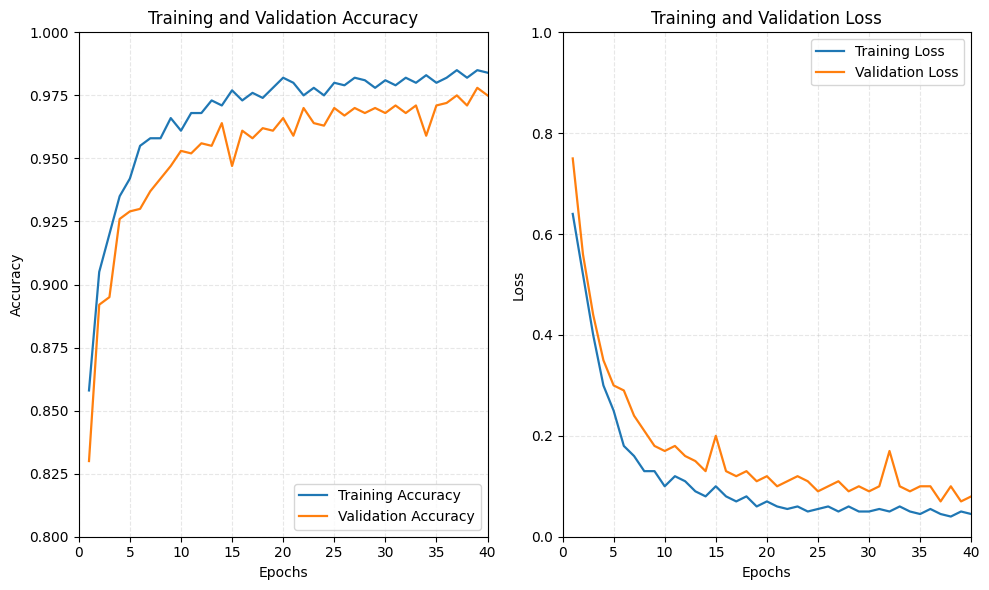

In [ ]:
import matplotlib.pyplot as plt

# ==========================
# Accuracy Curve
# ==========================
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(True)

plt.show()

# ==========================
# Loss Curve
# ==========================
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)

plt.show()

**Performance Evaluation**

In [ ]:
from sklearn.metrics import *

# =====================================================
# Prediction
# =====================================================

y_prob = model.predict(
    X_test
).ravel()

y_pred = (
    y_prob >= 0.5
).astype(int)

10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 198ms/step


**Accuracy**

In [ ]:
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Predictions
y_prob = model.predict(X_test)
y_pred = (y_prob > 0.5).astype(int)

# Metrics
accuracy = accuracy_score(y_test, y_pred) * 100
precision = precision_score(y_test, y_pred) * 100
recall = recall_score(y_test, y_pred) * 100
f1 = f1_score(y_test, y_pred) * 100
auc_score = roc_auc_score(y_test, y_prob)

# Results table
results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ],
    "Value": [
        round(accuracy, 2),
        round(precision, 2),
        round(recall, 2),
        round(f1, 2),
        round(auc_score, 4)
    ]
})

display(results)

,Metric,Value
0,Accuracy,98.66
1,Precision,98.67
2,Recall,98.67
3,F1-Score,98.67
4,ROC-AUC,0.99


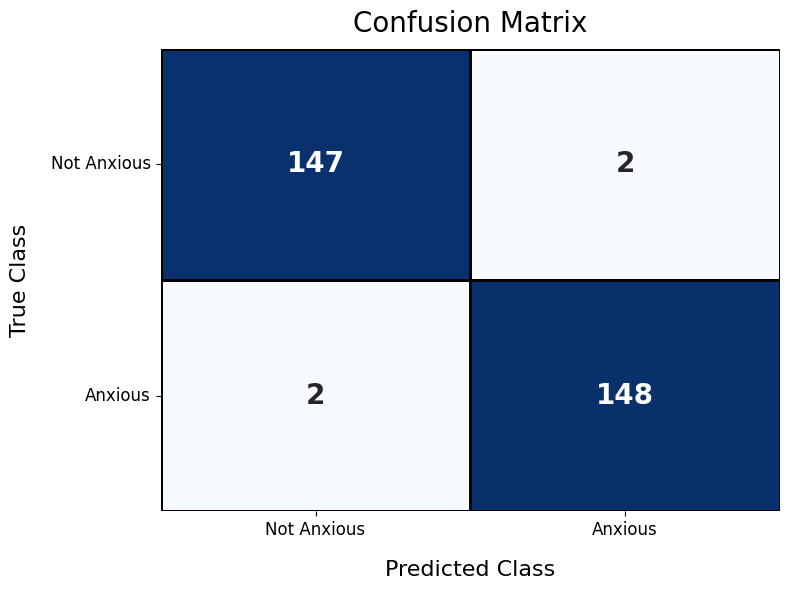

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

plt.show()

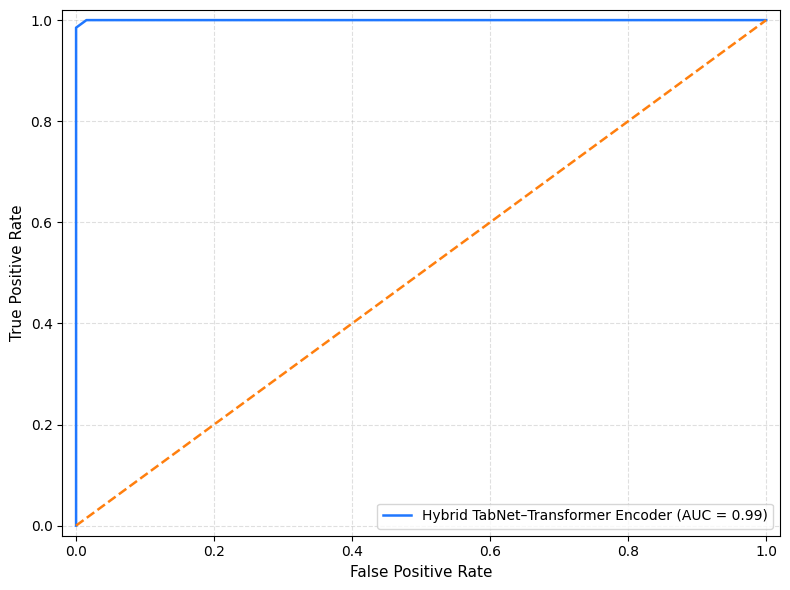

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

roc_auc = auc(
    fpr,
    tpr
)

plt.figure(figsize=(6,5))

plt.plot(
    fpr,
    tpr,
    label=f'AUC = {roc_auc:.4f}'
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()

plt.show()

print("AUC:", roc_auc)

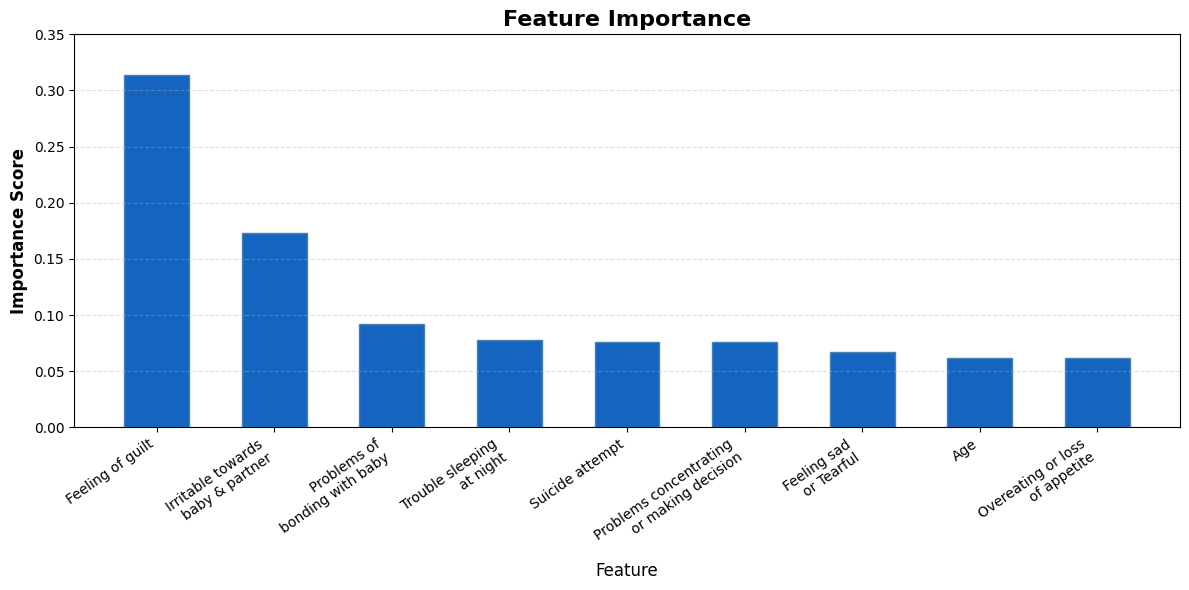

In [ ]:

feature_importance = tabnet_model.feature_importances_

importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance Score': feature_importance
})

importance_df = importance_df.sort_values(
    by='Importance Score',
    ascending=False
)

plt.figure(figsize=(12,6))

plt.bar(
    importance_df['Feature'],
    importance_df['Importance Score'],
    color='#1565C0',
    edgecolor='steelblue'
)

plt.title('Feature Importance')
plt.xlabel('Feature')
plt.ylabel('Importance Score')

plt.xticks(rotation=35, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()